In [1]:
# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text
from scipy.sparse import coo_matrix, csr_matrix
import statsmodels.formula.api as smf
from tqdm import tqdm
from scipy.sparse import csr_matrix

warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import * 

In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"

# But look at all the junctions that are in original anndata:
SPLICE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/072025/aligned_splicing_data_20250706_111436.h5ad"

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

# Read in full splice adata 
splice_adata_full = ad.read_h5ad(SPLICE_INPUT)

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df = atse_df[["junction_id", "perfect_match_5_prime", "perfect_match_3_prime"]]
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

In [3]:
# Junction ortho mapping
junc_orthos = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/plots_2025-07-05/junction_mapping_mouse_human_with_annotations.csv"
junc_orthos = pd.read_csv(junc_orthos)

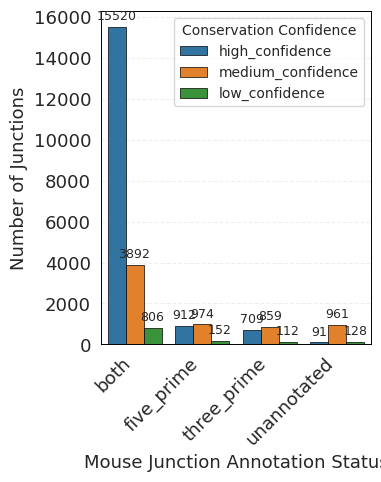

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12
})

fig, ax = plt.subplots(figsize=(4, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sns.countplot(
    data=junc_orthos,
    x="mouse_annotation_status",
    hue="conservation_confidence",
    hue_order=["high_confidence", "medium_confidence", "low_confidence"],
    palette=["#1f77b4", "#ff7f0e", "#2ca02c"],
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

ax.set_xlabel("Mouse Junction Annotation Status", fontsize=13)
ax.set_ylabel("Number of Junctions", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

ax.legend(
    title="Conservation Confidence",
    title_fontsize=10,
    fontsize=10,
    loc="upper right",
    frameon=True
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

# Make all spines black
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.7)

plt.tight_layout()
output_dir = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper"
# Save as PDF
plt.savefig(os.path.join(output_dir, 'annotation_status_barplot.pdf'), format='pdf', bbox_inches='tight')
plt.show()


In [5]:
# Initialize the column with default value
splice_adata_full.var["junction_conserved"] = "conservation_unknown"

# Create set of conserved junction IDs for fast lookup
conserved_junction_ids = set(junc_orthos["mouse_junction_id"])

print(f"Total junctions in splice_adata: {splice_adata_full.var.shape[0]:,}")
print(f"Conserved junctions in mapping: {len(conserved_junction_ids):,}")

# Mark conserved junctions
conserved_mask = splice_adata_full.var["junction_id"].isin(conserved_junction_ids)
splice_adata_full.var.loc[conserved_mask, "junction_conserved"] = "conserved"

# Summary statistics
conserved_count = (splice_adata_full.var["junction_conserved"] == "conserved").sum()
not_conserved_count = (splice_adata_full.var["junction_conserved"] == "conservation_unknown").sum()

print(f"\nConservation labeling results:")
print(f"  Conserved junctions: {conserved_count:,} ({conserved_count/len(splice_adata_full.var)*100:.1f}%)")
print(f"  Not conserved: {not_conserved_count:,} ({not_conserved_count/len(splice_adata_full.var)*100:.1f}%)")

Total junctions in splice_adata: 124,378
Conserved junctions in mapping: 25,116

Conservation labeling results:
  Conserved junctions: 23,040 (18.5%)
  Not conserved: 101,338 (81.5%)


In [6]:
# Ensure clean string format
splice_adata_full.var["annotation_conservation_group"] = (
    splice_adata_full.var["annotation_status"].astype(str) + "_" + splice_adata_full.var["junction_conserved"].astype(str)
)

In [7]:
# Convert age strings like "2m" to integer months
# subset for this analysis to no 2m old cells 
splice_adata_full.obs["age"] = splice_adata_full.obs["age"].str.replace("m", "").astype(int)

# Define young and old groups based on integer age
splice_adata_full.obs["age_group"] = splice_adata_full.obs["age"].apply(
    lambda x: "young" if x in [2, 3] else "old"
)

In [8]:
print("   Computing junction statistics...")
junction_matrix = splice_adata_full.layers["cell_by_junction_matrix"]
        
# Basic expression statistics
splice_adata_full.var["non_zero_count_cells"] = np.array((junction_matrix > 0).sum(axis=0)).flatten()
splice_adata_full.var["non_zero_cell_prop"] = splice_adata_full.var["non_zero_count_cells"] / splice_adata_full.shape[0]

# Total read counts across all cells for each junction
splice_adata_full.var["total_read_counts"] = np.array(junction_matrix.sum(axis=0)).flatten()

# Mean read counts per expressing cell
splice_adata_full.var["mean_counts_per_cell"] = np.where(
    splice_adata_full.var["non_zero_count_cells"] > 0,
    splice_adata_full.var["total_read_counts"] / splice_adata_full.var["non_zero_count_cells"],
    0
)

   Computing junction statistics...


In [9]:
# Get CSR matrices
A = splice_adata_full.layers["cell_by_junction_matrix"]  # numerator
B = splice_adata_full.layers["cell_by_cluster_matrix"]   # denominator

# Ensure shape matches
assert A.shape == B.shape

# Extract (row, col, data) of A
A_csr = A.tocsr()
B_csr = B.tocsr()

# Recover row indices from indptr
row_idx = np.repeat(np.arange(A_csr.shape[0]), np.diff(A_csr.indptr))
col_idx = A_csr.indices
A_data = A_csr.data

# Get corresponding B values at (row_idx, col_idx)
B_data = B_csr[row_idx, col_idx].A1  # .A1 flattens to 1D array

# Avoid divide by zero
safe_B_data = np.where(B_data == 0, np.nan, B_data)

# Compute element-wise ratio
ratio_data = A_data / safe_B_data

# Optionally replace nan with 0.0
ratio_data = np.nan_to_num(ratio_data, nan=0.0)

# Reconstruct result CSR matrix with same sparsity pattern as A
junc_ratio = csr_matrix((ratio_data, A_csr.indices, A_csr.indptr), shape=A_csr.shape)

# Store result
splice_adata_full.layers["junc_ratio"] = junc_ratio

### Make the same plot but showing raw junction read counts

In [10]:
# View counts per group
print(splice_adata_full.obs["age_group"].value_counts())

age_group
young    90890
old      57105
Name: count, dtype: int64


In [11]:
# Metadata
obs = splice_adata_full.obs.copy()
var = splice_adata_full.var
meta = obs[["age", "tissue"]].copy()
meta["age"] = meta["age"].astype(int)

# Matrix layers
psi_layer = splice_adata_full.layers["junc_ratio"]
count_layer = splice_adata_full.layers["cell_by_junction_matrix"]

# Group masks (used for sparse read count slices)
young_mask = obs["age_group"] == "young"
old_mask = obs["age_group"] == "old"

In [12]:
# Initialize container
delta_by_tissue = {}

# Step 1: Loop through tissues
for tissue in splice_adata_full.obs["tissue"].unique():
    if tissue == "Brain_Non-Myeloid":
        print(f"Skipping {tissue}")
        continue
    
    tissue_mask = splice_adata_full.obs["tissue"] == tissue
    young_mask = tissue_mask & (splice_adata_full.obs["age_group"] == "young")
    old_mask = tissue_mask & (splice_adata_full.obs["age_group"] == "old")

    # Skip tissues with too few cells in either group
    if young_mask.sum() < 500 or old_mask.sum() < 500:
        print(f"Skipping {tissue}")
        continue

    psi_young = splice_adata_full[young_mask].layers["junc_ratio"]
    psi_old = splice_adata_full[old_mask].layers["junc_ratio"]

    mean_psi_young = np.array(psi_young.mean(axis=0)).flatten()
    mean_psi_old = np.array(psi_old.mean(axis=0)).flatten()

    delta = mean_psi_old - mean_psi_young
    delta_by_tissue[tissue] = delta

# Step 2: Assemble tissue ΔPSIs into DataFrame
delta_df = pd.DataFrame(delta_by_tissue)  # shape: [n_junctions x n_tissues]
delta_df["junction_id"] = splice_adata_full.var["junction_id"].values

# Step 3: Merge into psi_summary
psi_summary = pd.DataFrame({
    "junction_id": splice_adata_full.var["junction_id"].values
})
psi_summary = psi_summary.merge(delta_df, on="junction_id")

# Step 4: Compute overall median ΔPSI across tissues
tissue_cols = [col for col in psi_summary.columns if col not in ["junction_id"]]
psi_summary["median_delta_psi_across_tissues"] = psi_summary[tissue_cols].median(axis=1)
psi_summary["max_delta_psi_across_tissues"] = psi_summary[tissue_cols].max(axis=1)

Skipping Mammary_Gland
Skipping Brain_Non-Myeloid
Skipping Kidney
Skipping Aorta


In [13]:
psi_summary["max_delta_psi_across_tissues"] = psi_summary[tissue_cols].abs().max(axis=1)

### Find exon skipping junctions

In [14]:
# Subset to ATSEs with exactly 3 junctions
atse_counts = splice_adata_full.var.groupby("event_id")["junction_id"].count()
candidate_atse = atse_counts[atse_counts == 3].index

# Pull junctions from those candidate ATSEs
subset = splice_adata_full.var[splice_adata_full.var["event_id"].isin(candidate_atse)].copy()

# Sort them by event_id and junction start
subset[["chr", "start", "end", "strand"]] = subset["junction_id"].str.extract(r"(chr[\w]+)_(\d+)_(\d+)_([+-])")
subset["start"] = subset["start"].astype(int)
subset["end"] = subset["end"].astype(int)
subset["event_id"] = subset["event_id"].astype(str)

from tqdm import tqdm

# Wrap the groupby apply with tqdm
grouped = subset.groupby("event_id")
results = []
for name, group in tqdm(grouped, total=len(grouped)):
    group = group.sort_values(["start", "end"])
    group["span"] = group["end"] - group["start"]
    group["skip_junction"] = group["span"] == group["span"].max()
    results.append(group)

subset = pd.concat(results)

100%|██████████| 9890/9890 [00:46<00:00, 212.79it/s]


In [15]:
# 1. Merge ΔPSI summary with junction metadata
psi_summary = psi_summary.merge(
    splice_adata_full.var[[
        "junction_id", "annotation_status", "junction_conserved",
        "total_read_counts", "non_zero_count_cells", "num_junctions",
        "non_zero_cell_prop", "mean_counts_per_cell"
    ]],
    on="junction_id",
    how="left"
)

# 3. Simplify annotation category
psi_summary["annotation_group"] = np.where(
    psi_summary["annotation_status"] == "both",
    "annotated",
    "unannotated"
)

# 4. Create combined label
psi_summary["annot_conserved"] = (
    psi_summary["annotation_group"] + " | " + psi_summary["junction_conserved"]
)

# 5. Add exon skipping flag if available
psi_summary["junction_id"] = psi_summary["junction_id"].astype(str)
subset["junction_id"] = subset["junction_id"].astype(str)

psi_summary = psi_summary.merge(
    subset[["junction_id", "skip_junction"]],
    on="junction_id",
    how="left"
)
psi_summary["skip_junction"] = psi_summary["skip_junction"].fillna(False)

In [16]:
# Get the index (column name) of the max absolute ΔPSI per row
idx_max_abs = psi_summary[tissue_cols].abs().idxmax(axis=1)

# Use those indices to extract the original (signed) values
psi_summary["max_delta_psi_across_tissues"] = psi_summary[tissue_cols].to_numpy()[np.arange(len(psi_summary)), psi_summary[tissue_cols].abs().values.argmax(axis=1)]

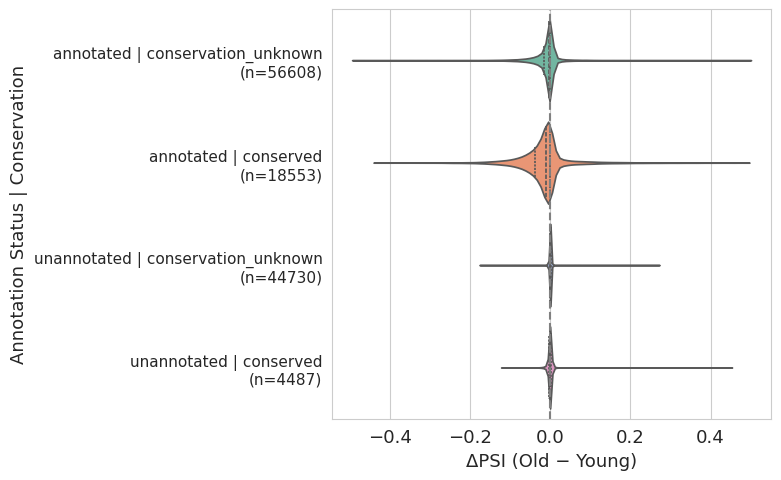

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df = psi_summary.copy()

# Count number of junctions per combination
group_counts = df["annot_conserved"].value_counts().to_dict()

# Function to generate label with count
def format_label(cat):
    count = group_counts.get(cat, 0)
    return f"{cat}\n(n={count})"

# Unique order and labels
yticks = sorted(df["annot_conserved"].unique())
ytick_labels = [format_label(y) for y in yticks]

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df,
    y="annot_conserved",
    x="max_delta_psi_across_tissues",
    order=yticks,
    inner="quart",
    cut=0,
    scale="width",
    palette="Set2"
)

plt.yticks(ticks=range(len(yticks)), labels=ytick_labels, fontsize=11)
plt.xlabel("ΔPSI (Old − Young)")
plt.ylabel("Annotation Status | Conservation")
plt.axvline(0, color="gray", linestyle="--")
plt.tight_layout()
plt.show()

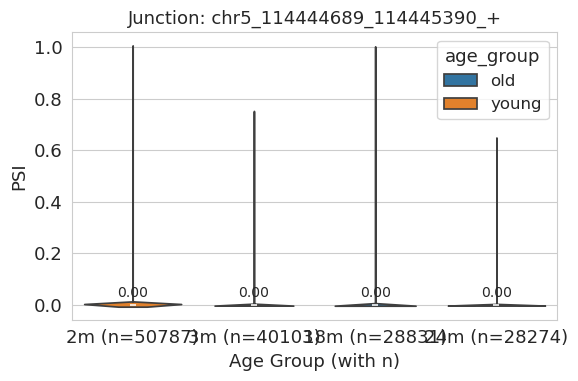

In [18]:
# 1. Pick a random junction index
junc_idx = 83891
junc_id = splice_adata_full.var["junction_id"].iloc[junc_idx]

# 2. Extract PSI values
psi_values = splice_adata_full.layers["junc_ratio"][:, junc_idx].toarray().ravel()

# 3. Build DataFrame
plot_df = pd.DataFrame({
    "PSI": psi_values,
    "age": splice_adata_full.obs["age"].values, 
    "age_group": splice_adata_full.obs["age_group"].values
})

# 4. Label and order
desired_ages = [2, 3, 18, 24]
age_counts = plot_df["age"].value_counts().sort_index()
label_map = {age: f"{age}m (n={age_counts.get(age, 0)})" for age in desired_ages}
plot_df["age_label"] = plot_df["age"].map(label_map)
plot_df["age_label"] = pd.Categorical(
    plot_df["age_label"],
    categories=[label_map[age] for age in desired_ages],
    ordered=True
)

# 5. Plot
plt.figure(figsize=(6, 4))
ax = sns.violinplot(data=plot_df, x="age_label", y="PSI", inner="box", hue="age_group")

# 6. Compute and annotate mean PSI values
means = plot_df.groupby("age_label")["PSI"].mean()
for i, (label, mean_val) in enumerate(means.items()):
    ax.text(i, mean_val + 0.02, f"{mean_val:.2f}", ha='center', va='bottom', fontsize=10)

# 7. Final formatting
plt.title(f"Junction: {junc_id}")
plt.ylabel("PSI")
plt.xlabel("Age Group (with n)")
plt.tight_layout()
plt.show()


In [19]:
psi_summary["abs_delta_psi"] = np.abs(psi_summary["max_delta_psi_across_tissues"])

In [20]:
# Summary statistics
print(psi_summary["max_delta_psi_across_tissues"].describe())

# % of junctions with high ΔPSI (e.g., >0.05)
high_delta_frac = (psi_summary["abs_delta_psi"] > 0.05).mean()
print(f"Fraction of junctions with |ΔPSI| > 0.05: {high_delta_frac:.2%}")

# Spearman correlation: ΔPSI vs # of cells with non-zero PSI
rho_cells = psi_summary["abs_delta_psi"].corr(psi_summary["non_zero_count_cells"], method="spearman")
rho_reads = psi_summary["abs_delta_psi"].corr(psi_summary["total_read_counts"], method="spearman")

print(f"Spearman ρ (|ΔPSI| vs non-zero cell count): {rho_cells:.2f}")
print(f"Spearman ρ (|ΔPSI| vs read count): {rho_reads:.2f}")



count    124378.000000
mean         -0.006264
std           0.041242
min          -0.494972
25%          -0.007915
50%          -0.001207
75%           0.000401
max           0.501171
Name: max_delta_psi_across_tissues, dtype: float64
Fraction of junctions with |ΔPSI| > 0.05: 9.64%
Spearman ρ (|ΔPSI| vs non-zero cell count): 0.70
Spearman ρ (|ΔPSI| vs read count): 0.80


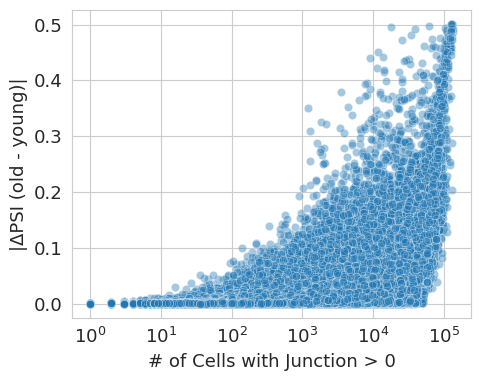

In [21]:
plt.figure(figsize=(5, 4))
sns.scatterplot(
    data=psi_summary,
    x="non_zero_count_cells",
    y="abs_delta_psi",
    alpha=0.4
)
plt.xscale("log")
plt.ylabel("|ΔPSI (old - young)|")
plt.xlabel("# of Cells with Junction > 0")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "cells_wjunc_vs_delta_psi.pdf"), format="pdf", bbox_inches="tight")
plt.show()

In [43]:
# Spearman correlation: ΔPSI vs # of cells with non-zero PSI
rho_ATSE = psi_summary["abs_delta_psi"].corr(psi_summary["non_zero_count_cells"], method="spearman")

print(f"Spearman ρ (|ΔPSI| vs non_zero_count_cells): {rho_ATSE:.2f}")

Spearman ρ (|ΔPSI| vs non_zero_count_cells): 0.70


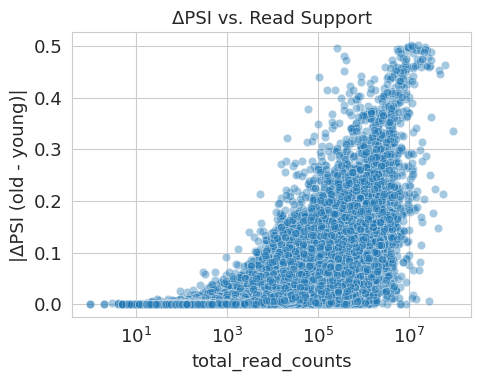

In [22]:
plt.figure(figsize=(5, 4))
sns.scatterplot(
    data=psi_summary,
    x="total_read_counts",
    y="abs_delta_psi",
    alpha=0.4
)
plt.xscale("log")
plt.ylabel("Total Junction Read Counts")
plt.ylabel("|ΔPSI (old - young)|")
plt.title("ΔPSI vs. Read Support")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "total_junc_reads_wjunc_vs_delta_psi.pdf"), format="pdf", bbox_inches="tight")
plt.show()


In [23]:
# Spearman correlation: ΔPSI vs # of cells with non-zero PSI
rho_ATSE = psi_summary["abs_delta_psi"].corr(psi_summary["num_junctions"], method="spearman")

print(f"Spearman ρ (|ΔPSI| vs num_junctions in ATSE): {rho_ATSE:.2f}")

Spearman ρ (|ΔPSI| vs num_junctions in ATSE): -0.24


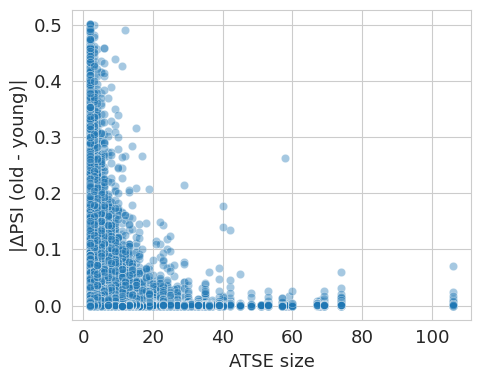

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.scatterplot(
    data=psi_summary,
    x="num_junctions",
    y="abs_delta_psi",
    alpha=0.4
)
#plt.xscale("log")
plt.ylabel("|ΔPSI (old - young)|")
plt.xlabel("ATSE size")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "ATSE_size_vs_delta_psi.pdf"), format="pdf", bbox_inches="tight")
plt.show()


In [31]:
# Fraction of junctions detected in <10% of cells
total_cells = splice_adata_full.n_obs

# Compute fraction of cells with nonzero PSI per junction
df["cell_detection_rate"] = df["non_zero_count_cells"] / total_cells

# Proportion of junctions detected in <10% of cells
frac_sparse_junctions = (df["cell_detection_rate"] < 0.1).mean()
print(f"Junctions detected in <10% of cells: {frac_sparse_junctions:.1%}")

# Fraction of junctions with low read support (e.g., total_read_counts < 50)
low_read_threshold = 1000
frac_low_read = (df["total_read_counts"] < low_read_threshold).mean()

print(f"Junctions with <{low_read_threshold} reads total: {frac_low_read:.1%}")

print(f">Junctions are sparsely detected:")
print(f"  • {frac_sparse_junctions:.1%} observed in <10% of cells")
print(f"  • {frac_low_read:.1%} supported by <{low_read_threshold} reads total")

Junctions detected in <10% of cells: 89.9%
Junctions with <1000 reads total: 34.7%
>Junctions are sparsely detected:
  • 89.9% observed in <10% of cells
  • 34.7% supported by <1000 reads total


In [42]:
# Compute average detection rate (%) for each annotation group
avg_detection_by_annotation = (
    df.groupby("annotation_group")["cell_detection_rate"]
    .mean()
    .mul(100)  # convert to percentage
    .round(1)
    .rename("avg_detection_rate_percent")
    .reset_index()
)

print(avg_detection_by_annotation)

  annotation_group  avg_detection_rate_percent
0        annotated                         5.3
1      unannotated                         0.3


In [26]:
# Make a copy to work with
df = psi_summary.copy()

# Bin coverage: use non-zero cell count or total reads
df["coverage_bin"] = pd.qcut(df["non_zero_count_cells"], q=2, labels=["low", "high"])

# Only keep rows with valid ΔPSI
df = df[df["max_delta_psi_across_tissues"].notna()]


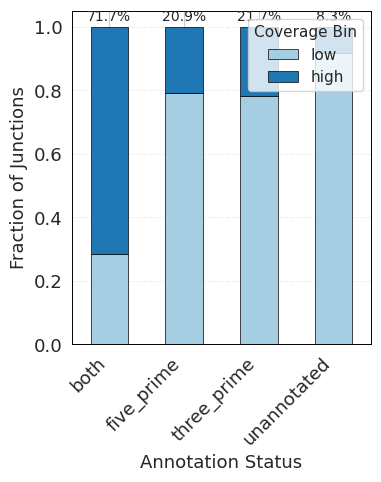

In [27]:
# ---------- Style Setup ----------
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12
})

# ---------- Data Aggregation ----------
coverage_counts = (
    df.groupby(["annotation_status", "coverage_bin"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["low", "high"], fill_value=0)  # ensure order
)

coverage_frac = coverage_counts.div(coverage_counts.sum(axis=1), axis=0)

# ---------- Plot Setup ----------
fig, ax = plt.subplots(figsize=(4, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

colors = ["#a6cee3", "#1f78b4"]
bar_container = coverage_frac.plot(
    kind="bar",
    stacked=True,
    color=colors,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# ---------- Axis and Labels ----------
ax.set_ylabel("Fraction of Junctions", fontsize=13)
ax.set_xlabel("Annotation Status", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)
ax.legend(title="Coverage Bin", title_fontsize=11, fontsize=11, loc="upper right", frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# ---------- Add fraction labels on top of high bin ----------
for i, status in enumerate(coverage_frac.index):
    frac = coverage_frac.loc[status, "high"]
    total = coverage_counts.loc[status].sum()
    percent = frac * 100
    ax.text(i, 1.01, f"{percent:.1f}%", ha="center", va="bottom", fontsize=10)

# ---------- Set spines ----------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.7)

# ---------- Save ----------
plt.tight_layout()
output_dir = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper"
plt.savefig(os.path.join(output_dir, "annotation_status_vs_coverage.pdf"), format="pdf", bbox_inches="tight")
plt.show()


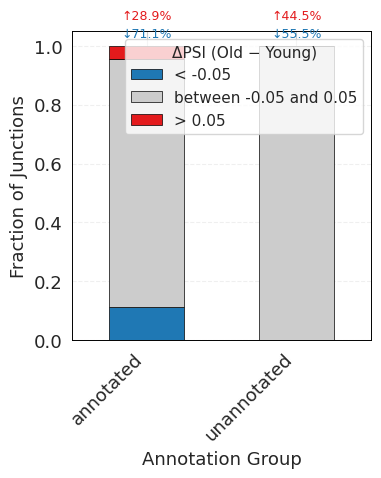

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Step 1: Categorize ΔPSI with direction preserved
def categorize_delta(val):
    if pd.isna(val):
        return "NaN"
    elif val < -0.05:
        return "< -0.05"
    elif val > 0.05:
        return "> 0.05"
    else:
        return "between -0.05 and 0.05"

df["delta_psi_category"] = df["max_delta_psi_across_tissues"].apply(categorize_delta)

# Step 2: Use `annotation_group` instead of `annotation_status`
delta_counts = (
    df.groupby(["annotation_group", "delta_psi_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["< -0.05", "between -0.05 and 0.05", "> 0.05"], fill_value=0)
)

# Normalize to fractions
delta_frac = delta_counts.div(delta_counts.sum(axis=1), axis=0)

# Step 3: Plot settings
fig, ax = plt.subplots(figsize=(4,5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Color palette
colors = {
    "< -0.05": "#1f78b4",                  # Blue
    "between -0.05 and 0.05": "#cccccc",   # Gray
    "> 0.05": "#e31a1c",                   # Red
}

# Stacked barplot
delta_frac.plot(
    kind="bar",
    stacked=True,
    color=[colors[c] for c in delta_frac.columns],
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# Axis labels and formatting
ax.set_ylabel("Fraction of Junctions", fontsize=13)
ax.set_xlabel("Annotation Group", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)
ax.legend(title="ΔPSI (Old − Young)", title_fontsize=11, fontsize=11, loc="upper right", frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Step 4: Annotate % above bars for both directions
for i, status in enumerate(delta_frac.index):
    down = delta_counts.loc[status, "< -0.05"]
    up = delta_counts.loc[status, "> 0.05"]
    total_extreme = down + up

    if total_extreme > 0:
        down_pct = 100 * down / total_extreme
        up_pct = 100 * up / total_extreme
        ax.text(i, 1.02, f"↓{down_pct:.1f}%", ha="center", va="bottom", fontsize=9, color="#1f78b4")
        ax.text(i, 1.08, f"↑{up_pct:.1f}%", ha="center", va="bottom", fontsize=9, color="#e31a1c")
# Final style
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.7)

# Save and show
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "annotation_group_delta_psi_direction.pdf"), format="pdf", bbox_inches="tight")
plt.show()


In [29]:
delta_counts

delta_psi_category,< -0.05,between -0.05 and 0.05,> 0.05
annotation_group,,,
annotated,8412,63331,3418
unannotated,91,49053,73
